# 06 — Exit surface and stop manager

The biggest grid in the project. Holds entry rule constant and varies stop_pct
× target_pct × max_hold_days × stop_manager_models. Default grid size is
``4 × 4 × 3 × 3 = 144`` variants per candidate. Output: ``cf_exit.parquet``
plus a gap-through diagnostic addressing the high ``stop_gap`` rate seen in
the IEX baseline.


In [1]:
# Notebook bootstrap cell. Keep this in every bowaka_lab notebook.
from pathlib import Path
import sys

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "research_notebooks").exists():
    repo_root = repo_root.parent

bowaka_project = repo_root / "research_notebooks" / "bowaka_lab"
src_path = bowaka_project / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import bowaka_lab
from bowaka_lab.utils.env import load_project_dotenv

_loaded_env = load_project_dotenv()
print(f"bowaka_lab {bowaka_lab.__version__}")
print(
    f"bowaka_lab bootstrap: .env loaded from {_loaded_env}"
    if _loaded_env
    else "bowaka_lab bootstrap: no .env found (env vars must be set in shell)"
)


bowaka_lab 0.1.0
bowaka_lab bootstrap: .env loaded from /quants-lab/.env


## Configuration

In [2]:
import os

RUN_ID                    = "bt_iex_default"
DATA_ROOT                 = os.environ.get(
    "BOWAKA_DATA_ROOT",
    "research_notebooks/bowaka_lab/db_tools/bowaka_data",
)
ARTIFACTS_ROOT            = "research_notebooks/bowaka_lab/artifacts"
FEED                      = "iex"
REBUILD                   = False

ENTRY_RULE                = "fixed_time_0945"
STOP_PCTS                 = [0.05, 0.08, 0.10, 0.12]
TARGET_PCTS               = [0.10, 0.15, 0.20, 0.25]
MAX_HOLD_DAYS_LIST        = [1, 3, 5]
STOP_MANAGER_MODELS       = ["none", "breakeven_after_5pct", "mfe_ladder_v1"]
SIGNAL_FADE_THRESHOLD     = None
INCLUDE_REJECTED          = False


## Derived paths + config

In [3]:
from pathlib import Path

import pandas as pd

from bowaka_lab.config.models import CounterfactualConfig
from bowaka_lab.data.parquet_io import MinuteBarLoader
from bowaka_lab.sim.counterfactuals import run_grid_for_candidates
from bowaka_lab.sim.fill_model import BowakaFillModel
from bowaka_lab.utils import (
    ArtifactPaths,
    artifact_exists,
    load_parquet,
    save_parquet,
)


data_root      = Path(DATA_ROOT)      if Path(DATA_ROOT).is_absolute()      else (repo_root / DATA_ROOT).resolve()
artifacts_root = Path(ARTIFACTS_ROOT) if Path(ARTIFACTS_ROOT).is_absolute() else (repo_root / ARTIFACTS_ROOT).resolve()
MINUTE_ROOT    = data_root / "parquet/bars/vendor=alpaca" / f"feed={FEED}" / "timeframe=1m/adjustment=raw"

paths = ArtifactPaths.for_run(RUN_ID, artifacts_root)
paths.ensure_dir()
assert paths.candidates.exists(), (
    f"candidates artifact missing: {paths.candidates}\n"
    "Run notebook 03_prefilter_replay first."
)

cf_cfg = CounterfactualConfig(
    include_rejected_candidates=INCLUDE_REJECTED,
    entry_rules=[ENTRY_RULE],
    stop_pct=STOP_PCTS,
    target_pct=TARGET_PCTS,
    max_hold_days=MAX_HOLD_DAYS_LIST,
    signal_fade_thresholds=[SIGNAL_FADE_THRESHOLD],
    stop_manager_models=STOP_MANAGER_MODELS,
)
fill_model = BowakaFillModel(slippage_bps=25.0)
minute_loader = MinuteBarLoader(MINUTE_ROOT)
grid_size = len(STOP_PCTS) * len(TARGET_PCTS) * len(MAX_HOLD_DAYS_LIST) * len(STOP_MANAGER_MODELS)
print(f"artifacts:  {paths.root}")
print(f"grid size:  {grid_size} variants per candidate")


artifacts:  /quants-lab/research_notebooks/bowaka_lab/artifacts/bt_iex_default
grid size:  144 variants per candidate


## Load candidates

In [4]:
candidates_df = load_parquet(paths.candidates)
print(f"candidates loaded: {candidates_df.shape[0]:,} rows over "
      f"{candidates_df['signal_date'].nunique():,} signal dates")


candidates loaded: 1,593 rows over 306 signal dates


## Build + run exit-surface grid

In [5]:
outcomes_df = None

if not REBUILD and artifact_exists(paths, "cf_exit"):
    print("Fast path: cf_exit.parquet exists; loading.")
    outcomes_df = load_parquet(paths.cf_exit)
else:
    print("Running exit-surface grid per signal date (this is the biggest grid)...")
    all_rows = []
    grouped = candidates_df.groupby("signal_date", sort=True)
    n_sessions = len(grouped)
    for i, (sd, group) in enumerate(grouped, start=1):
        trade_date = group["trade_date"].iloc[0]
        symbols = group["symbol"].astype(str).tolist()
        bars_per_session = minute_loader(trade_date, symbols)
        bars_by_symbol = (
            {s: g.copy() for s, g in bars_per_session.groupby("symbol", sort=False)}
            if not bars_per_session.empty else {}
        )
        out = run_grid_for_candidates(
            candidates=group.reset_index(drop=True),
            minute_bars_by_symbol=bars_by_symbol,
            cfg=cf_cfg,
            fill_model=fill_model,
            signal_date=sd,
            trade_date=trade_date,
        )
        if not out.empty:
            all_rows.append(out)
        if i % 10 == 0:
            print(f"  {i}/{n_sessions} sessions processed")
    outcomes_df = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()
    save_parquet(paths.cf_exit, outcomes_df)
    print(f"wrote {paths.cf_exit}")

print(f"outcomes rows: {outcomes_df.shape[0]:,}")


Running exit-surface grid per signal date (this is the biggest grid)...
  10/306 sessions processed
  20/306 sessions processed
  30/306 sessions processed
  40/306 sessions processed
  50/306 sessions processed
  60/306 sessions processed
  70/306 sessions processed
  80/306 sessions processed
  90/306 sessions processed
  100/306 sessions processed
  110/306 sessions processed
  120/306 sessions processed
  130/306 sessions processed
  140/306 sessions processed
  150/306 sessions processed
  160/306 sessions processed
  170/306 sessions processed
  180/306 sessions processed
  190/306 sessions processed
  200/306 sessions processed
  210/306 sessions processed
  220/306 sessions processed
  230/306 sessions processed
  240/306 sessions processed
  250/306 sessions processed
  260/306 sessions processed
  270/306 sessions processed
  280/306 sessions processed
  290/306 sessions processed
  300/306 sessions processed
wrote /quants-lab/research_notebooks/bowaka_lab/artifacts/bt_iex_de

## Heatmap: median pnl_pct by (stop_pct, target_pct)

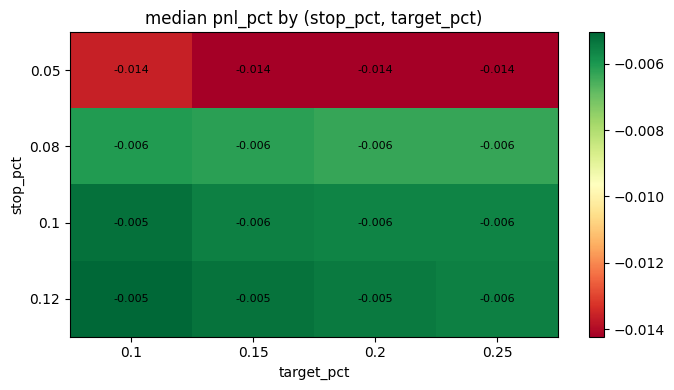

In [6]:
if outcomes_df.empty:
    print("no outcomes to plot")
else:
    df = outcomes_df.copy()
    # Pull variant keys into top-level columns. variant arrives either as a
    # dict (Parquet preserved the struct) or a JSON string (to_parquet_safe
    # serialised it). Handle both.
    if isinstance(df["variant"].iloc[0], dict):
        var_df = pd.json_normalize(df["variant"])
    else:
        import json as _json
        var_df = pd.json_normalize(df["variant"].map(_json.loads))
    var_df.index = df.index
    df = pd.concat([df.drop(columns=["variant"]), var_df], axis=1)

    entered = df[df["would_enter"]]
    pivot = entered.pivot_table(
        index="stop_pct", columns="target_pct", values="pnl_pct", aggfunc="median",
    )
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(7, 4))
        im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("target_pct")
        ax.set_ylabel("stop_pct")
        ax.set_title("median pnl_pct by (stop_pct, target_pct)")
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                v = pivot.values[i, j]
                ax.text(j, i, f"{v:.3f}" if pd.notna(v) else "", ha="center", va="center", fontsize=8)
        fig.colorbar(im, ax=ax)
        fig.tight_layout()
        plt.show()
    except Exception:
        print(pivot.to_string())


## Stop-manager comparison

In [7]:
if not outcomes_df.empty:
    if isinstance(outcomes_df["variant"].iloc[0], dict):
        var_df = pd.json_normalize(outcomes_df["variant"])
    else:
        import json as _json
        var_df = pd.json_normalize(outcomes_df["variant"].map(_json.loads))
    var_df.index = outcomes_df.index
    df = pd.concat([outcomes_df.drop(columns=["variant"]), var_df], axis=1)
    entered = df[df["would_enter"]]
    by_mgr = entered.groupby("stop_manager_model").agg(
        trades=("pnl_pct", "size"),
        win_rate=("pnl_pct", lambda s: float((s > 0).mean())),
        median_pnl_pct=("pnl_pct", "median"),
    ).reset_index().sort_values("median_pnl_pct", ascending=False)
    try:
        from IPython.display import display
        display(by_mgr)
    except Exception:
        print(by_mgr.to_string(index=False))


,stop_manager_model,trades,win_rate,median_pnl_pct
1,mfe_ladder_v1,75120,0.396645,-0.005370
0,breakeven_after_5pct,75120,0.374042,-0.005611
2,none,75120,0.413299,-0.010760


## Gap-through diagnostic

In [8]:
if not outcomes_df.empty:
    if isinstance(outcomes_df["variant"].iloc[0], dict):
        var_df = pd.json_normalize(outcomes_df["variant"])
    else:
        import json as _json
        var_df = pd.json_normalize(outcomes_df["variant"].map(_json.loads))
    var_df.index = outcomes_df.index
    df = pd.concat([outcomes_df.drop(columns=["variant"]), var_df], axis=1)

    entered = df[df["would_enter"]].copy()
    entered["is_stop_gap"] = entered["exit_reason"] == "stop_gap"
    gap_table = entered.groupby(["stop_pct", "max_hold_days"]).agg(
        trades=("pnl_pct", "size"),
        stop_gap_rate=("is_stop_gap", "mean"),
    ).reset_index()
    print("Stop-gap rate by (stop_pct, max_hold_days):")
    try:
        from IPython.display import display
        display(gap_table)
    except Exception:
        print(gap_table.to_string(index=False))
    print()
    print("Overall stop_gap share of exits:")
    if "exit_reason" in entered.columns:
        share = entered["is_stop_gap"].mean()
        print(f"  {share:.2%}")


Stop-gap rate by (stop_pct, max_hold_days):


,stop_pct,max_hold_days,trades,stop_gap_rate
0,0.05,1,18780,0.181310
1,0.05,3,18780,0.181310
2,0.05,5,18780,0.181310
3,0.08,1,18780,0.096006
4,0.08,3,18780,0.096006
5,0.08,5,18780,0.096006
6,0.10,1,18780,0.070820
7,0.10,3,18780,0.070820
8,0.10,5,18780,0.070820
9,0.12,1,18780,0.053355



Overall stop_gap share of exits:
  10.04%


## Next

- **`notebooks/07_signal_fade_study.ipynb`** for the signal-fade analysis.
- Or jump straight to **`notebooks/11_weekly_research_report.ipynb`** to
  aggregate.